In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display, HTML

display(HTML("""
<style>
.output_scroll {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

In [2]:
sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook"
)



In [3]:
df = pd.read_csv("/Users/hardikmehta/Downloads/store_customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


# Univariate Analysis

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

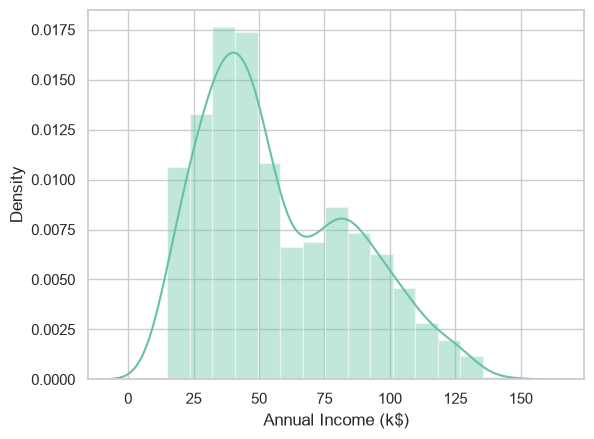

In [6]:
sns.distplot(df["Annual Income (k$)"])

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

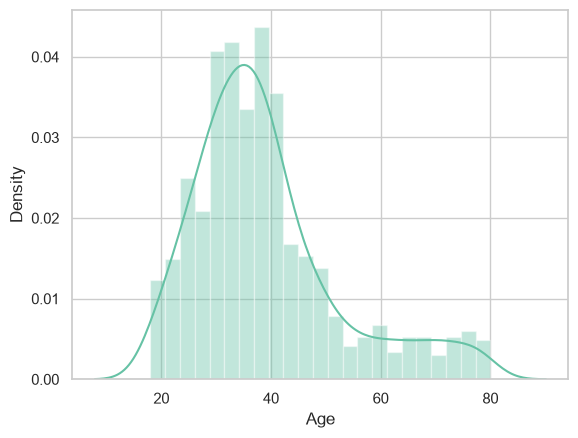

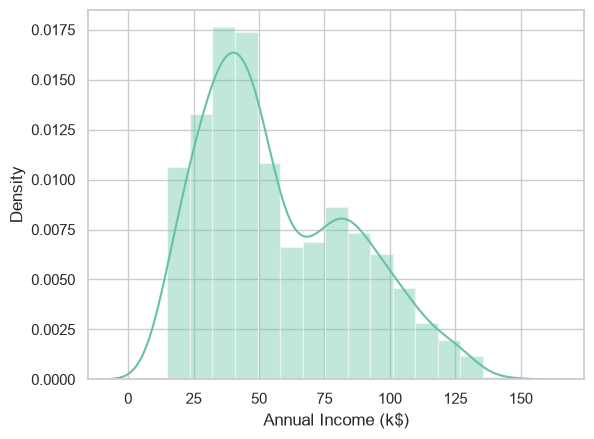

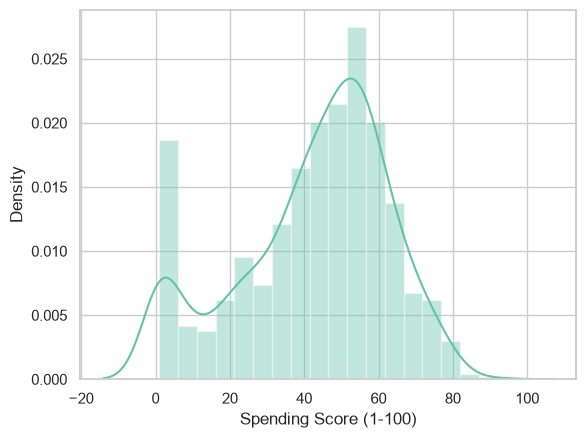

In [8]:
columns =['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.distplot(df[i])
    

<Axes: xlabel='Annual Income (k$)', ylabel='Density'>

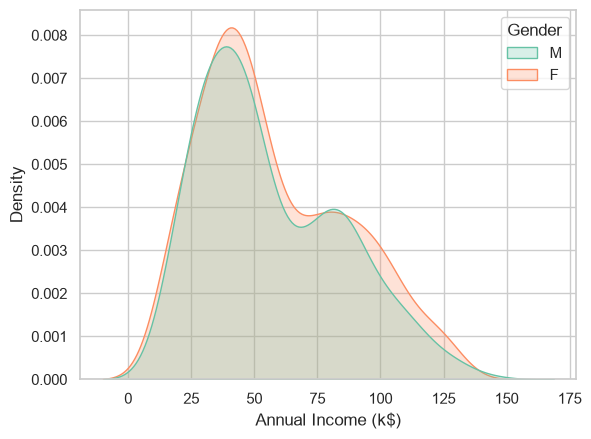

In [9]:
sns.kdeplot( data=df,x="Annual Income (k$)", hue="Gender",fill=True)

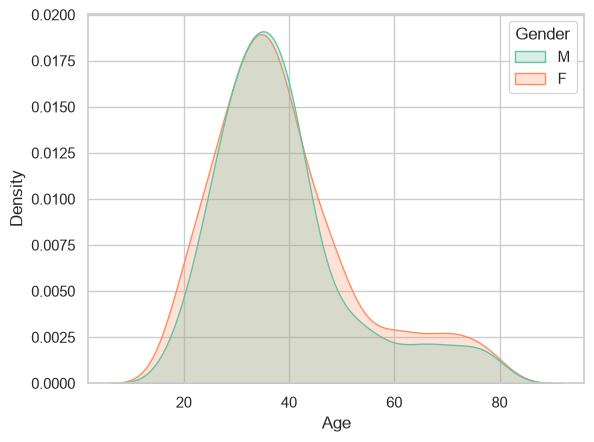

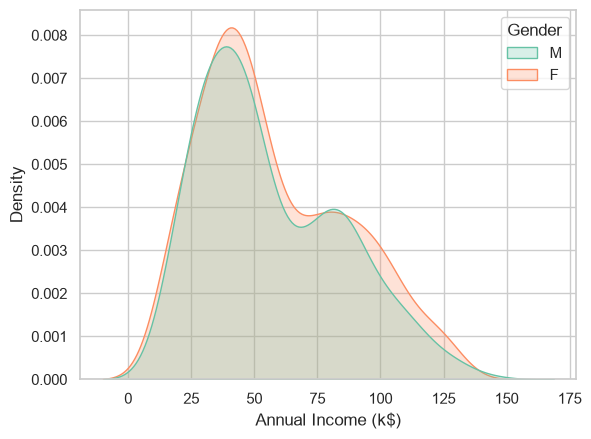

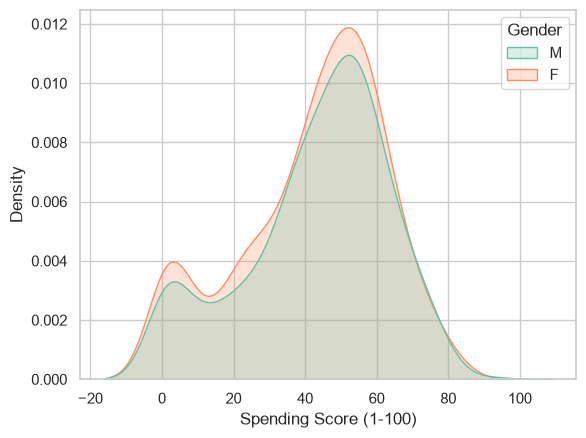

In [10]:
columns =['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.kdeplot( data=df,x=i, hue="Gender",fill=True)

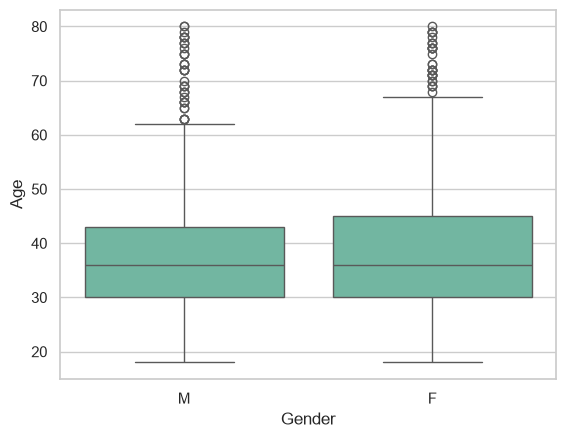

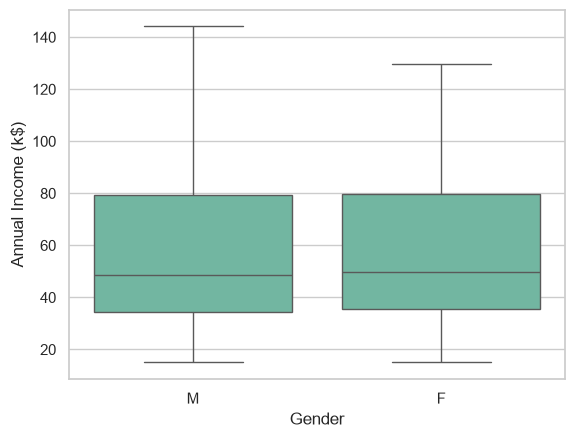

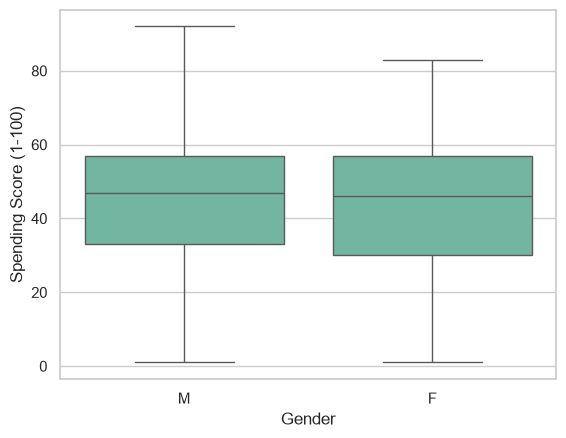

In [11]:
columns =['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in columns:
    plt.figure()
    sns.boxplot(data = df, x= "Gender" , y = df[i] )

In [12]:
df["Gender"].value_counts(normalize = True)

Gender
F    0.523571
M    0.476429
Name: proportion, dtype: float64

# Bivariate Analysis

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

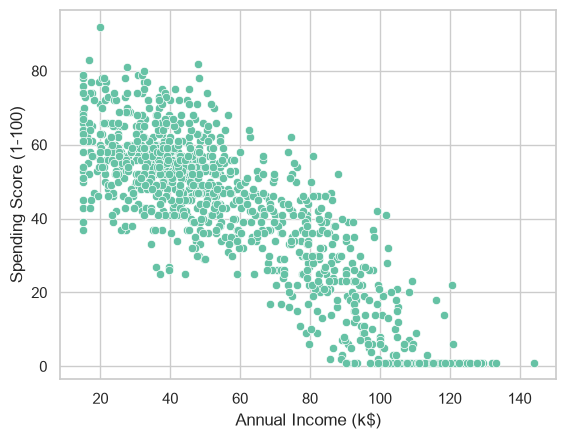

In [15]:
sns.scatterplot(data = df, x = "Annual Income (k$)" , y = "Spending Score (1-100)")

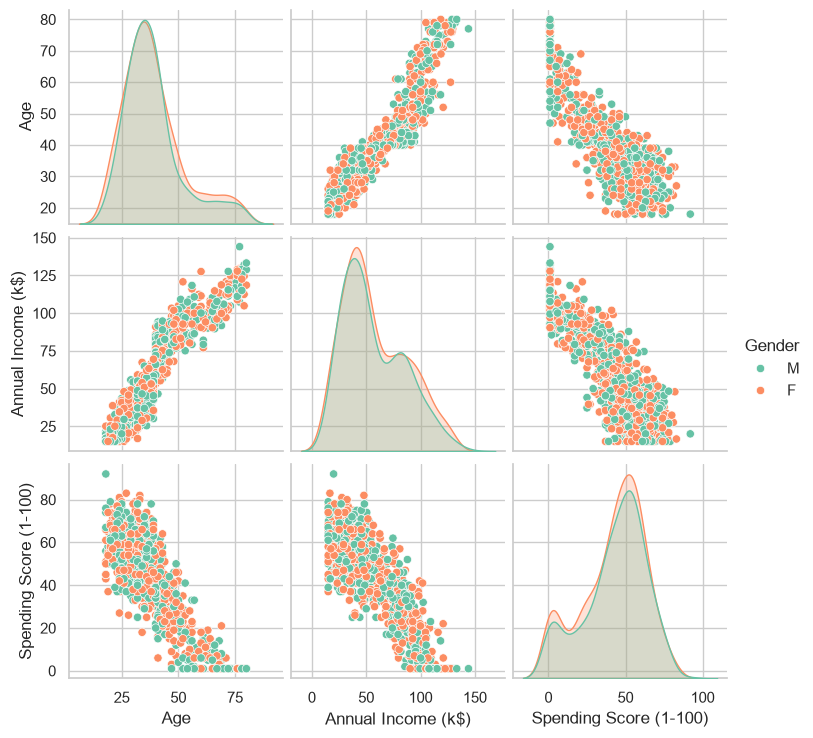

In [18]:
#df = df.drop("CustomerID", axis =1)

sns.pairplot(df,hue = "Gender")

In [20]:
df.groupby("Gender")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
F,39.110039,57.798649,42.273603
M,38.742072,56.433053,43.082452


In [22]:
df.corr(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,0.923913,-0.835186
Annual Income (k$),0.923913,1.000000,-0.846073
Spending Score (1-100),-0.835186,-0.846073,1.000000


<Axes: >

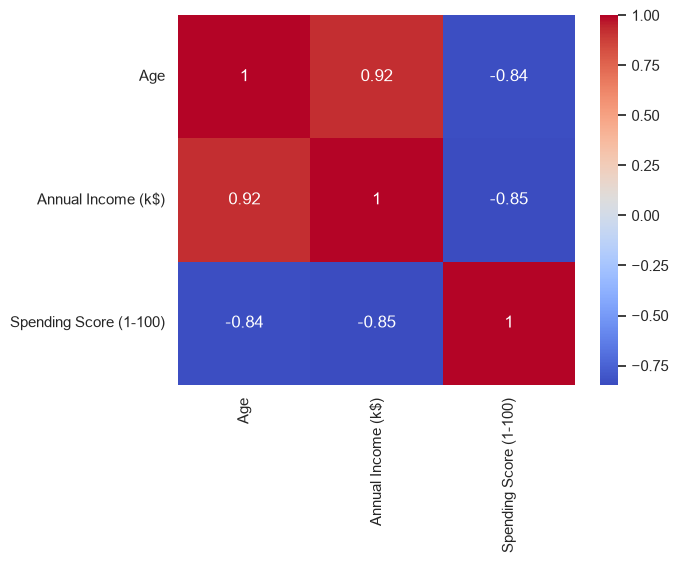

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap = "coolwarm")

# Clustering - Univariate, Bivariate, Multivariate

In [36]:
clustering1 = KMeans()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  997 non-null    str    
 1   Age                     994 non-null    float64
 2   Annual Income (k$)      996 non-null    float64
 3   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), str(1)
memory usage: 32.5 KB


In [30]:
X = df[["Annual Income (k$)"]].dropna()

clustering1 = KMeans(n_clusters = )
clustering1.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 1)",

In [31]:
clustering1.labels_

array([4, 1, 2, 5, 1, 6, 5, 2, 1, 1, 3, 1, 1, 3, 3, 6, 1, 4, 1, 3, 5, 1,
       1, 6, 3, 4, 3, 1, 3, 4, 6, 0, 1, 3, 4, 6, 1, 3, 6, 4, 5, 4, 1, 6,
       3, 6, 6, 2, 4, 3, 4, 6, 6, 2, 5, 2, 3, 6, 1, 2, 6, 6, 3, 3, 5, 2,
       1, 2, 1, 6, 2, 5, 6, 0, 3, 4, 4, 4, 1, 3, 4, 4, 5, 1, 1, 6, 5, 4,
       6, 4, 6, 2, 1, 1, 1, 3, 4, 1, 1, 1, 6, 6, 1, 1, 1, 1, 0, 4, 1, 1,
       3, 1, 1, 0, 6, 1, 1, 3, 2, 2, 2, 1, 2, 6, 2, 0, 6, 1, 4, 6, 6, 4,
       3, 4, 1, 5, 1, 4, 2, 3, 4, 5, 3, 4, 1, 2, 3, 1, 2, 1, 1, 4, 6, 1,
       4, 3, 5, 1, 3, 5, 3, 5, 5, 6, 5, 4, 5, 5, 1, 6, 3, 6, 2, 4, 1, 2,
       4, 5, 1, 5, 2, 6, 6, 6, 1, 2, 4, 6, 3, 1, 5, 4, 6, 4, 1, 6, 1, 4,
       3, 1, 4, 5, 2, 3, 6, 1, 1, 4, 0, 5, 5, 4, 2, 1, 5, 3, 6, 4, 4, 5,
       3, 4, 3, 1, 5, 1, 6, 6, 2, 6, 1, 6, 1, 5, 2, 3, 6, 6, 2, 4, 6, 2,
       5, 6, 4, 1, 1, 5, 4, 6, 2, 5, 2, 3, 1, 5, 6, 4, 2, 1, 6, 3, 6, 4,
       3, 2, 6, 6, 1, 2, 3, 2, 6, 1, 4, 4, 6, 1, 1, 4, 5, 2, 6, 5, 4, 2,
       4, 1, 1, 6, 1, 5, 1, 6, 2, 4, 2, 2, 1, 1, 2,

In [45]:
df = df.dropna(subset=["Annual Income (k$)"])

X = df[["Annual Income (k$)"]]

clustering1 = KMeans(n_clusters=3, random_state=42)
clustering1.fit(X)

df["Income cluster"] = clustering1.labels_

In [46]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income cluster
0,M,39.0,59.9,58.0,2
1,M,34.0,48.4,37.0,0
2,F,40.0,70.5,26.0,2
3,F,47.0,81.1,30.0,2
4,F,33.0,42.1,58.0,0


In [47]:
df["Income cluster"].value_counts() 

Income cluster
0    568
2    256
1    172
Name: count, dtype: int64

In [48]:
clustering1.inertia_

118256.15529407124

In [49]:
inertia_scores = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    inertia_scores.append(kmeans.inertia_)

In [50]:
inertia_scores

[815493.409186747,
 201387.10545997194,
 118281.9653850554,
 62235.73021267887,
 42278.82564253476,
 29162.821909021408,
 20933.44059476322,
 17071.67083335577,
 13590.786633630032,
 11349.490072574354]

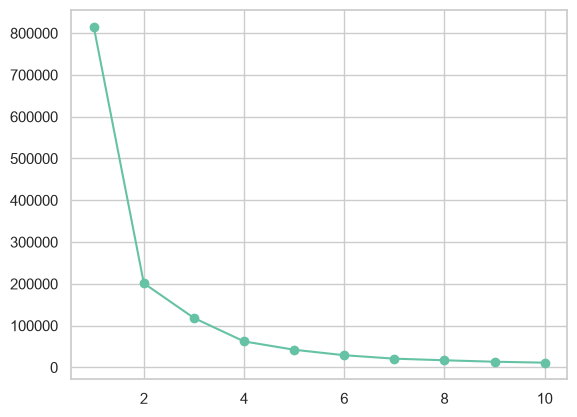

In [51]:
plt.plot(range(1,11), inertia_scores, marker="o")

In [52]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income cluster'],
      dtype='str')

In [54]:
df.groupby("Income cluster")[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income cluster,,,
0,30.440497,36.051408,55.095915
1,61.604651,104.608721,10.540698
2,42.447059,72.072656,36.862745


# Bivariate Clustering



In [66]:
df = df.dropna(subset=["Annual Income (k$)", "Spending Score (1-100)"])
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
clustering2 = KMeans(n_clusters = 5)
clustering2.fit(X)
df["Spending and Income Cluster"] = clustering2.labels_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income cluster,Spending and Income Cluster
0,M,39.0,59.9,58.0,2,3
1,M,34.0,48.4,37.0,0,0
2,F,40.0,70.5,26.0,2,4
3,F,47.0,81.1,30.0,2,4
4,F,33.0,42.1,58.0,0,0


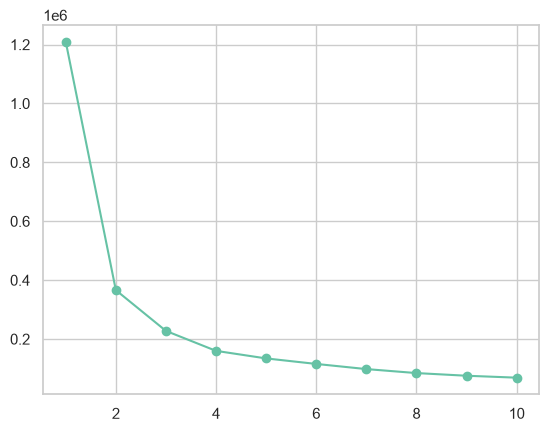

In [67]:
inertia_scores2= []

for i in range(1, 11):
    kmeans2 = KMeans(n_clusters=i)
    kmeans2.fit(X)
    inertia_scores2.append(kmeans2.inertia_)
plt.plot(range(1,11), inertia_scores2, marker="o")

In [75]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ["x" , "y"]

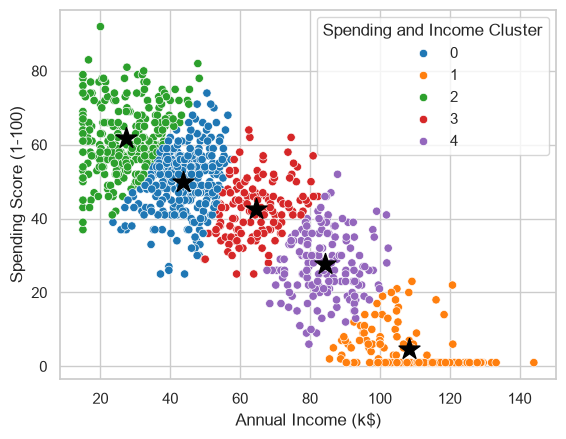

In [164]:
plt.figure
plt.scatter(x = centers["x"], y = centers["y"], c = "black", marker = "*",s = 250, zorder = 10)
sns.scatterplot(data = df, x = "Annual Income (k$)", y = "Spending Score (1-100)" , hue = "Spending and Income Cluster", palette = "tab10" )
plt.savefig("clustering_bivariate.png")


In [86]:
pd.crosstab(df["Spending and Income Cluster"], df["Gender"], normalize = "index")

Gender,F,M
Spending and Income Cluster,,
0,0.532895,0.467105
1,0.535433,0.464567
2,0.500000,0.500000
3,0.517986,0.482014
4,0.525000,0.475000


In [87]:
df.groupby("Spending and Income Cluster")[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,33.324503,43.619016,50.108197
1,65.992126,108.287402,4.787402
2,27.019531,27.292636,61.825581
3,39.755396,64.670504,42.633094
4,46.550000,84.362112,27.726708


In [161]:
df


,Gender,Age,Annual Income (k$),Spending Score (1-100),Income cluster,Spending and Income Cluster
0,M,39.0,59.9,58.0,2,3
1,M,34.0,48.4,37.0,0,0
2,F,40.0,70.5,26.0,2,4
3,F,47.0,81.1,30.0,2,4
4,F,33.0,42.1,58.0,0,0
...,...,...,...,...,...,...
995,M,80.0,133.3,1.0,1,1
996,M,44.0,82.6,40.0,2,4
997,F,46.0,67.7,26.0,2,4
998,F,28.0,45.7,59.0,0,0


In [163]:
df.to_csv("Clustering.csv")